In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("car_details_v4_1.csv")
df

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,Honda,Amaze 1.2 VX i-VTEC,505000,2017,87150,Petrol,Manual,Pune,Grey,First,Corporate,1198 cc,87 bhp @ 6000 rpm,109 Nm @ 4500 rpm,FWD,3990.0,1680.0,1505.0,5.0,35.0
1,Maruti Suzuki,Swift DZire VDI,450000,2014,75000,Diesel,Manual,Ludhiana,White,Second,Individual,1248 cc,74 bhp @ 4000 rpm,190 Nm @ 2000 rpm,FWD,3995.0,1695.0,1555.0,5.0,42.0
2,Hyundai,i10 Magna 1.2 Kappa2,220000,2011,67000,Petrol,Manual,Lucknow,Maroon,First,Individual,1197 cc,79 bhp @ 6000 rpm,112.7619 Nm @ 4000 rpm,FWD,3585.0,1595.0,1550.0,5.0,35.0
3,Toyota,Glanza G,799000,2019,37500,Petrol,Manual,Mangalore,Red,First,Individual,1197 cc,82 bhp @ 6000 rpm,113 Nm @ 4200 rpm,FWD,3995.0,1745.0,1510.0,5.0,37.0
4,Toyota,Innova 2.4 VX 7 STR [2016-2020],1950000,2018,69000,Diesel,Manual,Mumbai,Grey,First,Individual,2393 cc,148 bhp @ 3400 rpm,343 Nm @ 1400 rpm,RWD,4735.0,1830.0,1795.0,7.0,55.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2054,Mahindra,XUV500 W8 [2015-2017],850000,2016,90300,Diesel,Manual,Surat,White,First,Individual,2179 cc,138 bhp @ 3750 rpm,330 Nm @ 1600 rpm,FWD,4585.0,1890.0,1785.0,7.0,70.0
2055,Hyundai,Eon D-Lite +,275000,2014,83000,Petrol,Manual,Ahmedabad,White,Second,Individual,814 cc,55 bhp @ 5500 rpm,75 Nm @ 4000 rpm,FWD,3495.0,1550.0,1500.0,5.0,32.0
2056,Ford,Figo Duratec Petrol ZXI 1.2,240000,2013,73000,Petrol,Manual,Thane,Silver,First,Individual,1196 cc,70 bhp @ 6250 rpm,102 Nm @ 4000 rpm,FWD,3795.0,1680.0,1427.0,5.0,45.0
2057,BMW,5-Series 520d Luxury Line [2017-2019],4290000,2018,60474,Diesel,Automatic,Coimbatore,White,First,Individual,1995 cc,188 bhp @ 4000 rpm,400 Nm @ 1750 rpm,RWD,4936.0,1868.0,1479.0,5.0,65.0


In [3]:
df.shape

(2059, 20)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2059 entries, 0 to 2058
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Make                2059 non-null   object 
 1   Model               2059 non-null   object 
 2   Price               2059 non-null   int64  
 3   Year                2059 non-null   int64  
 4   Kilometer           2059 non-null   int64  
 5   Fuel Type           2059 non-null   object 
 6   Transmission        2059 non-null   object 
 7   Location            2059 non-null   object 
 8   Color               2059 non-null   object 
 9   Owner               2059 non-null   object 
 10  Seller Type         2059 non-null   object 
 11  Engine              2059 non-null   object 
 12  Max Power           2059 non-null   object 
 13  Max Torque          2059 non-null   object 
 14  Drivetrain          2059 non-null   object 
 15  Length              2059 non-null   float64
 16  Width 

In [5]:
df.describe()

,Price,Year,Kilometer,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
count,2.059000e+03,2059.000000,2.059000e+03,2059.000000,2059.000000,2059.000000,2059.000000,2059.000000
mean,1.702992e+06,2016.425449,5.422471e+04,4283.631374,1768.054395,1590.282661,5.296746,51.892326
std,2.419881e+06,3.363564,5.736172e+04,435.799127,133.146412,134.186875,0.811029,14.696588
min,4.900000e+04,1988.000000,0.000000e+00,3099.000000,1475.000000,1165.000000,2.000000,15.000000
25%,4.849990e+05,2014.000000,2.900000e+04,3986.000000,1695.000000,1485.000000,5.000000,42.000000
50%,8.250000e+05,2017.000000,5.000000e+04,4370.000000,1770.000000,1545.000000,5.000000,50.000000
75%,1.925000e+06,2019.000000,7.200000e+04,4620.000000,1831.000000,1672.000000,5.000000,60.000000
max,3.500000e+07,2022.000000,2.000000e+06,5569.000000,2220.000000,1995.000000,8.000000,105.000000


In [6]:
df.isnull().sum()

,0
Make,0
Model,0
Price,0
Year,0
Kilometer,0
Fuel Type,0
Transmission,0
Location,0
Color,0
Owner,0


In [7]:
df.dropna(inplace=True)
print("Shape after dropping nulls:", df.shape)

Shape after dropping nulls: (2059, 20)


In [8]:
# Extract numeric part from 'Engine' column (e.g. '1198 cc' -> 1198)
df['Engine'] = df['Engine'].str.extract(r'(\d+)').astype(float)

# Extract numeric part from 'Max Power' column (e.g. '87 bhp @ 6000 rpm' -> 87)
df['Max Power'] = df['Max Power'].str.extract(r'([\d.]+)').astype(float)

# Extract numeric part from 'Max Torque' column (e.g. '109 Nm @ 4500 rpm' -> 109)
df['Max Torque'] = df['Max Torque'].str.extract(r'([\d.]+)').astype(float)

df[['Engine', 'Max Power', 'Max Torque']].head()

,Engine,Max Power,Max Torque
0,1198.0,87.0,109.0000
1,1248.0,74.0,190.0000
2,1197.0,79.0,112.7619
3,1197.0,82.0,113.0000
4,2393.0,148.0,343.0000


In [9]:
df.dropna(inplace=True)
print("Shape after cleaning:", df.shape)

Shape after cleaning: (2059, 20)


In [11]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

categorical_cols = ['Make', 'Model', 'Fuel Type', 'Transmission', 'Location',
                    'Color', 'Owner', 'Seller Type', 'Drivetrain']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Make,Model,Price,Year,Kilometer,Fuel Type,Transmission,Location,Color,Owner,Seller Type,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity
0,7,106,505000,2017,87150,6,1,56,7,1,1,1198.0,87.0,109.0000,1,3990.0,1680.0,1505.0,5.0,35.0
1,19,802,450000,2014,75000,2,1,40,15,3,2,1248.0,74.0,190.0000,1,3995.0,1695.0,1555.0,5.0,42.0
2,8,1030,220000,2011,67000,6,1,39,8,1,2,1197.0,79.0,112.7619,1,3585.0,1595.0,1550.0,5.0,35.0
3,30,492,799000,2019,37500,6,1,41,13,1,2,1197.0,82.0,113.0000,1,3995.0,1745.0,1510.0,5.0,37.0
4,30,548,1950000,2018,69000,2,1,45,7,1,2,2393.0,148.0,343.0000,2,4735.0,1830.0,1795.0,7.0,55.0


## **EDA**

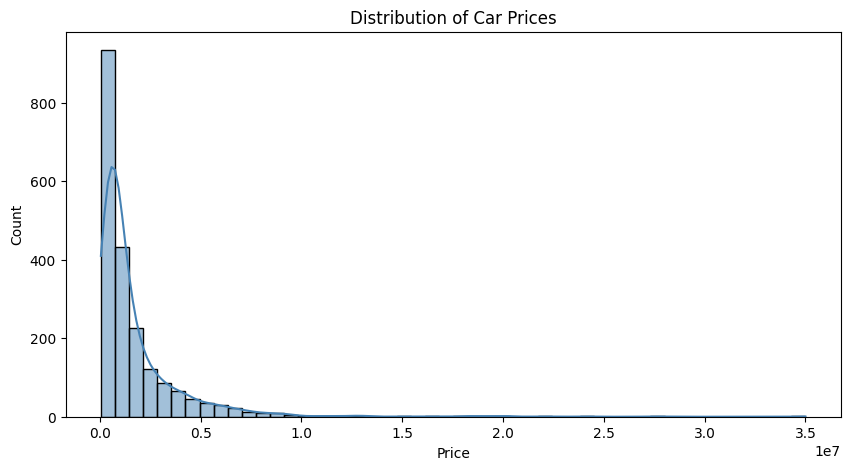

In [12]:
# Distribution of Price
plt.figure(figsize=(10, 5))
sns.histplot(df['Price'], bins=50, kde=True, color='steelblue')
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

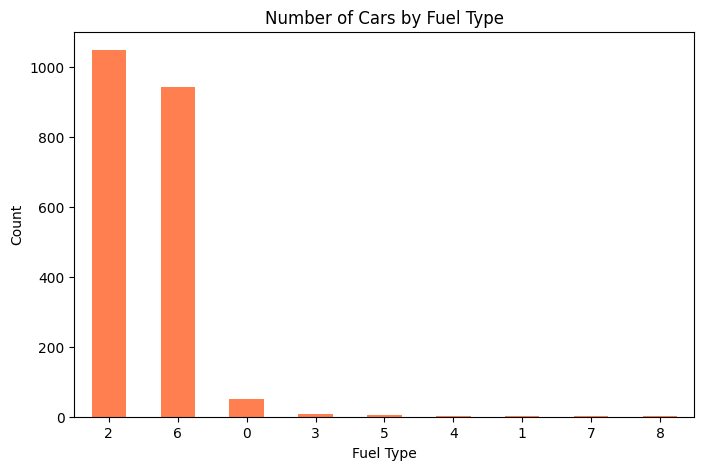

In [13]:
# Count of cars by Fuel Type (before encoding, reload for plot if needed)
plt.figure(figsize=(8, 5))
df['Fuel Type'].value_counts().plot(kind='bar', color='coral')
plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

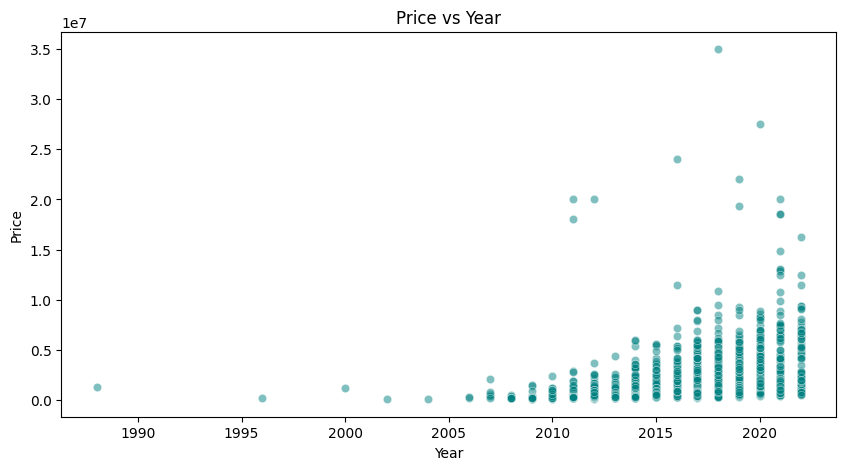

In [14]:
# Price vs Year
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Year', y='Price', data=df, alpha=0.5, color='teal')
plt.title("Price vs Year")
plt.xlabel("Year")
plt.ylabel("Price")
plt.show()

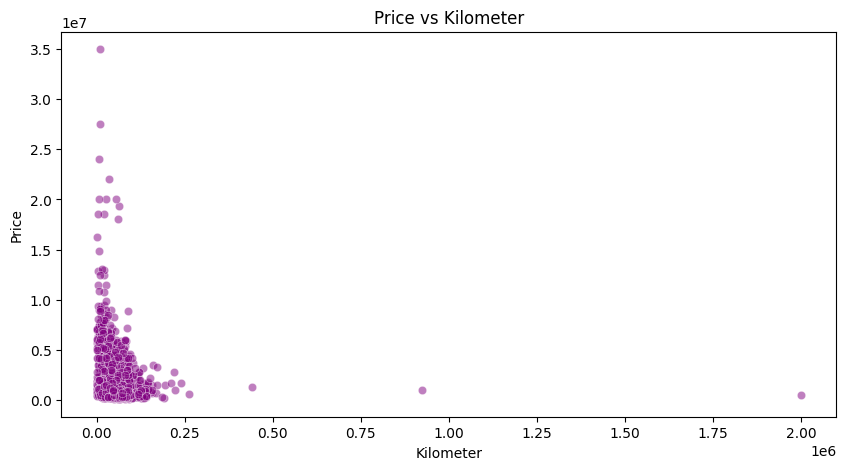

In [15]:
# Price vs Kilometer
plt.figure(figsize=(10, 5))
sns.scatterplot(x='Kilometer', y='Price', data=df, alpha=0.5, color='purple')
plt.title("Price vs Kilometer")
plt.xlabel("Kilometer")
plt.ylabel("Price")
plt.show()

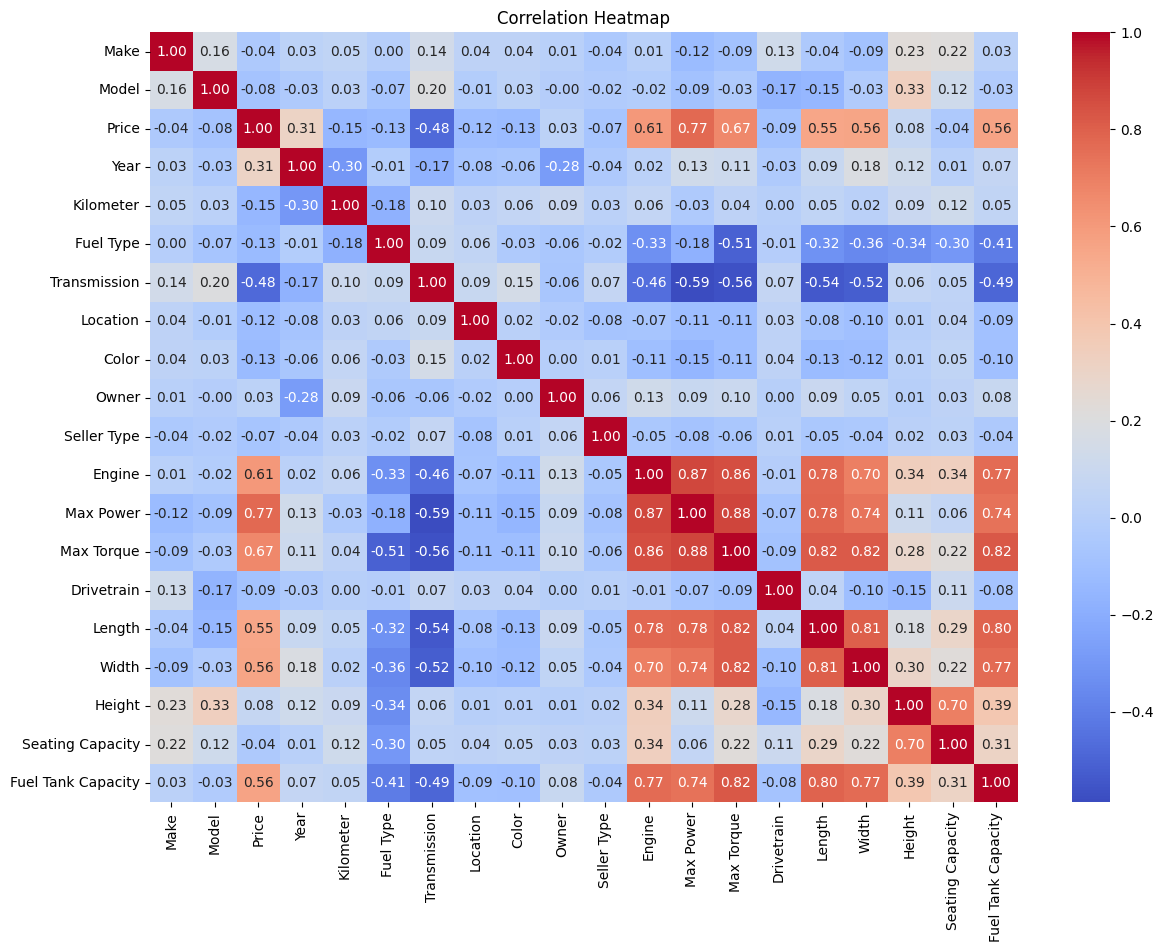

In [16]:
# To see relationships
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [17]:
# We predict: Price
# So - Features = X , Target = y
X = df.drop('Price', axis=1)
y = df['Price']

## **Split Dataset**

In [19]:
# We divide data into:
# Training data -> model learns
# Testing data  -> model tested
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## **Feature Scaling**

In [20]:
# Scaling improves accuracy.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Simple Linear Regression

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X_train_simple = X_train[:, 0].reshape(-1, 1)
X_test_simple = X_test[:, 0].reshape(-1, 1)

# Create model
simple_model = LinearRegression()
# Train model
simple_model.fit(X_train_simple, y_train)
# Predict
y_pred_simple = simple_model.predict(X_test_simple)
# Evaluate
simple_r2 = r2_score(y_test, y_pred_simple)
print("Simple Linear Regression R2 Score:", simple_r2)

Simple Linear Regression R2 Score: 0.0011254078755864594


## Multiple Linear Regression

In [24]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)
y_pred_multiple = multiple_model.predict(X_test)
multiple_r2 = r2_score(y_test, y_pred_multiple)
print("Multiple Linear Regression R2 Score:", multiple_r2)

Multiple Linear Regression R2 Score: 0.7130771272469372


## Polynomial Regression

In [26]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)
y_pred_poly = poly_model.predict(X_test_poly)
poly_r2 = r2_score(y_test, y_pred_poly)
print("Polynomial Regression R2 Score:", poly_r2)

Polynomial Regression R2 Score: 0.8107134032495967


## Decision Tree Regression

In [28]:
from sklearn.tree import DecisionTreeRegressor
decision_model = DecisionTreeRegressor(random_state=42)
decision_model.fit(X_train, y_train)
y_pred_decision = decision_model.predict(X_test)
decision_r2 = r2_score(y_test, y_pred_decision)
print("Decision Tree Regression R2 Score:", decision_r2)

Decision Tree Regression R2 Score: 0.7993811618118527


## Random Forest Regression

In [29]:
from sklearn.ensemble import RandomForestRegressor
random_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
random_model.fit(X_train, y_train)
y_pred_random = random_model.predict(X_test)
random_r2 = r2_score(y_test, y_pred_random)
print("Random Forest Regression R2 Score:", random_r2)

Random Forest Regression R2 Score: 0.8186807678837331


## Final Model - Random Forest Regression (with full metrics)

In [30]:
# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=1000,
    max_depth=20,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
# Train model
rf_model.fit(X_train, y_train)
# Predict on test data
y_pred_rf = rf_model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# R2 Score
rf_r2 = r2_score(y_test, y_pred_rf)
# MAE
rf_mae = mean_absolute_error(y_test, y_pred_rf)
# MSE
rf_mse = mean_squared_error(y_test, y_pred_rf)
# RMSE
rf_rmse = np.sqrt(rf_mse)

# Print results
print("Random Forest Regression Results:")
print("R2 Score :", rf_r2)
print("MAE      :", rf_mae)
print("MSE      :", rf_mse)
print("RMSE     :", rf_rmse)

Random Forest Regression Results:
R2 Score : 0.7818528020693376
MAE      : 323003.8970695445
MSE      : 1524037883518.0947
RMSE     : 1234519.292485174
